<a href="https://colab.research.google.com/github/Sangeetha231005/MLops-training/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Disaster Detection and Classification :**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Crisis/final_updated_dataset.csv')
df.shape

(2433, 5)

In [ ]:
df.head()

,index,event,class_label,clean_text,has_crisis_term
0,0,other_disaster,requests_or_needs,people in central of haiti need help. overcrow...,True
1,1,earthquake,injured_or_dead_people,very sad news 2 consecutive blasts in qisa kha...,True
2,2,hurricane,donation_and_volunteering,heres how cfb teams are responding to hurrican...,True
3,3,other_disaster,requests_or_needs,were hungry we need some food and water please,False
4,4,other_disaster,requests_or_needs,medicine and tent needed. we are counting on y...,False


In [ ]:
df['clean_text'] = df['clean_text'].fillna('')

**Converting Text into Vectors using TF-IDF :**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=7000,
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X = tfidf.fit_transform(df['clean_text'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['class_label'])

**Train and Test split :**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(1946, 4071)
(487, 4071)


**Using Logistic Regression With Balanced weights :**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_lrb = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)
model_lrb.fit(X_train, y_train)
y_pred_lrb = model_lrb.predict(X_test)
accuracy_lrb = accuracy_score(y_test, y_pred_lrb)
print("Logistic Regression Accuracy:", accuracy_lrb)

Logistic Regression Accuracy: 0.784394250513347


**Using K-Fold Cross validation for accuracy in Logistic Regression :**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000,class_weight='balanced')

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Average Accuracy:", scores.mean())

[0.78439425 0.73511294 0.77823409 0.77366255 0.76954733]
Average Accuracy: 0.7681902299287653


**Classification Reports :**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lrb))

              precision    recall  f1-score   support

           0       0.78      0.60      0.68        67
           1       0.79      0.79      0.79       148
           2       0.69      0.79      0.74        92
           3       0.75      0.76      0.75        50
           4       0.88      0.88      0.88       130

    accuracy                           0.78       487
   macro avg       0.78      0.76      0.77       487
weighted avg       0.79      0.78      0.78       487



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lrb)
print(cm)

[[ 40   9  11   5   2]
 [  4 117  13   3  11]
 [  5   8  73   4   2]
 [  2   3   6  38   1]
 [  0  12   3   1 114]]


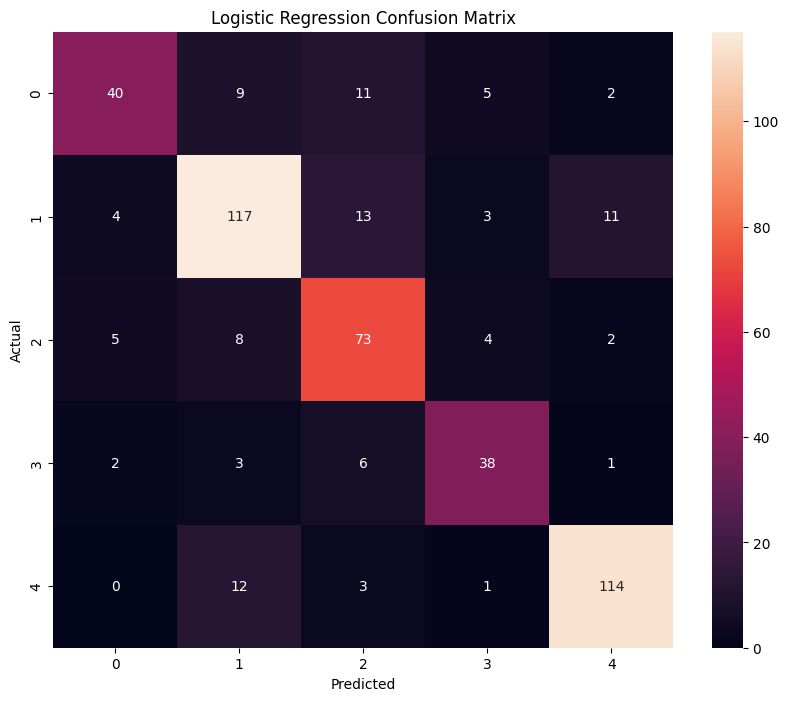

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

**Predicting Non Disaster using Decision Score :**

In [ ]:
import numpy as np
def predict_crisis(text):
    text_tfidf = tfidf.transform([text])
    scores = model_lr.decision_function(text_tfidf)
    max_score = np.max(scores)
    THRESHOLD = 0.5
    if max_score < THRESHOLD:
        return "Non-Disaster Message"
    pred = model_svm.predict(text_tfidf)
    label = encoder.inverse_transform(pred)
    return label[0]

In [ ]:
text = "i am watching a movie with my friends"
print(predict_crisis(text))

Non-Disaster Message


**Using Logistic regression Without balanced weights :**

In [ ]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=2000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7371663244353183


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.46      0.60        67
           1       0.67      0.89      0.77       148
           2       0.70      0.67      0.69        92
           3       0.84      0.42      0.56        50
           4       0.81      0.87      0.84       130

    accuracy                           0.74       487
   macro avg       0.77      0.66      0.69       487
weighted avg       0.75      0.74      0.73       487



In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[ 31  18   9   3   6]
 [  0 132   5   1  10]
 [  4  20  62   0   6]
 [  2  12  10  21   5]
 [  0  15   2   0 113]]


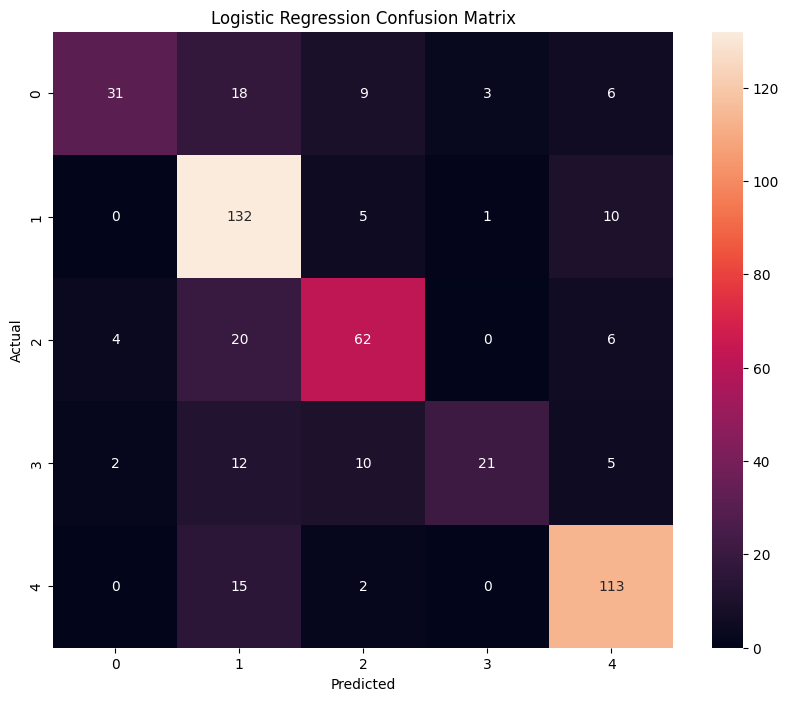

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

**Using SVM With Balanced Weights :**

In [ ]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC(
    class_weight='balanced',
    max_iter=5000
)

model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Balanced SVM Accuracy:", accuracy_svm)

Balanced SVM Accuracy: 0.7700205338809035


**Using Naives Bayes :**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()

model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.6940451745379876


**Using Random Forest :**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7125256673511293


**Using Decision Tree :**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.6016427104722792


**Using KNN :**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.5934291581108829


**Model comparision :**

In [ ]:
models = [
    "Logistic Regression Balanced",
    "Logistic Regression",
    "SVM Balanced",
    "Naive Bayes",
    "Random Forest",
    "Decision Tree",
    "KNN"
]

In [ ]:
accuracies = [
    accuracy_lrb,
    accuracy_lr,
    accuracy_svm,
    accuracy_nb,
    accuracy_rf,
    accuracy_dt,
    accuracy_knn
]


In [ ]:
comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

In [ ]:
print(comparison_df)

                          Model  Accuracy
0  Logistic Regression Balanced  0.784394
1           Logistic Regression  0.737166
2                  SVM Balanced  0.770021
3                   Naive Bayes  0.694045
4                 Random Forest  0.712526
5                 Decision Tree  0.601643
6                           KNN  0.593429


In [ ]:
best_accuracy = max(accuracies)
best_model = models[accuracies.index(best_accuracy)]
print("Best Model :", best_model)
print("Best Accuracy :", best_accuracy)

Best Model : Logistic Regression Balanced
Best Accuracy : 0.784394250513347


**Generating them as pickle file :**

In [ ]:
import pickle
with open('crisis_model.pkl', 'wb') as file:
    pickle.dump(model_lrb, file)
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(encoder, file)
print("Pickle files saved successfully")

Pickle files saved successfully
